The purpose of this notebook is to conduct an exploratory analysis of the Mitchell et al. (2011) data and figure out what data processing is necessary to conduct analysis. 

I also want to run AR(1) processes to figure out if they are good matches for the Mitchell data.

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.signal import lombscargle
from scipy.ndimage import gaussian_filter1d
from astropy.timeseries import LombScargle

from methane_noise_forcing import compute_ar1_params_from_tau, generate_ar1_noise

# import data and format

In [2]:
path_methane = "/Users/ericm/Documents/Research/intro_and_motivation_figs/data/ch4/past_2000/WDC05A_mitchell2011.csv"

age_col = 'Gas Age (Year C.E., timescale:"WDC05A:2")'
df = pd.read_csv(
    path_methane, usecols=["Mean depth (m)", age_col, "Mean Concentration (ppb)"]
).rename(columns={age_col: "Gas_Age_CE"})

df["Gas_Age_CE"] = df["Gas_Age_CE"].astype(float)

df.head()

,Mean depth (m),Gas_Age_CE,Mean Concentration (ppb)
0,109.215,1814.20,739.273119
1,110.490,1808.78,742.922299
2,110.880,1807.67,737.708567
3,112.930,1799.91,735.613533
4,113.160,1798.93,731.514054


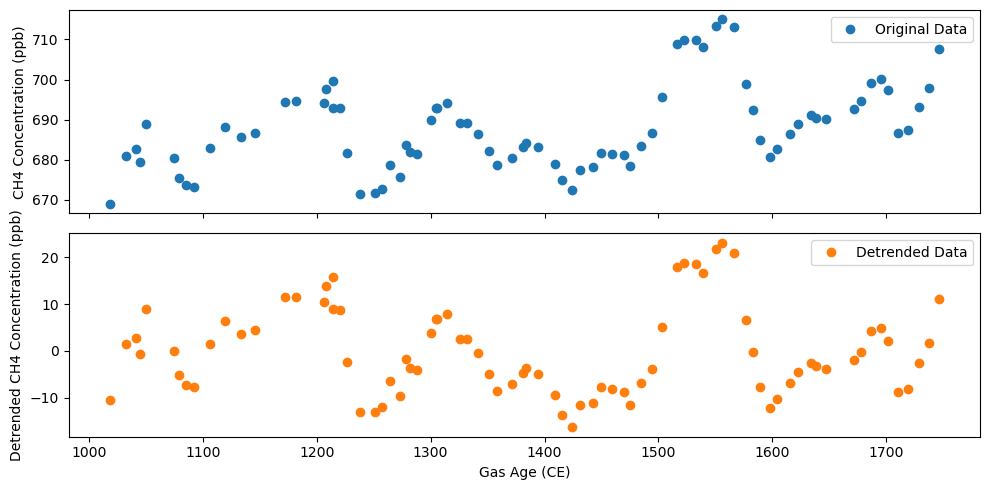

In [3]:
# filter data: max gas age is 1750 CE
df_filtered = df[df["Gas_Age_CE"] <= 1750].copy()
mitchell_time = df_filtered["Gas_Age_CE"].values
mitchell_ch4 = df_filtered["Mean Concentration (ppb)"].values

# detrend data
coeffs = np.polyfit(mitchell_time, mitchell_ch4, 1)
mitchell_ch4_detrended = mitchell_ch4 - np.polyval(coeffs, mitchell_time)

# plot data
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axs[0].plot(mitchell_time, mitchell_ch4, "o", label="Original Data")
axs[0].set_ylabel("CH4 Concentration (ppb)")
axs[0].legend()
axs[1].plot(
    mitchell_time,
    mitchell_ch4_detrended,
    "o",
    label="Detrended Data",
    color="tab:orange",
)
axs[1].set_xlabel("Gas Age (CE)")
axs[1].set_ylabel("Detrended CH4 Concentration (ppb)")
axs[1].legend()
plt.tight_layout()

# Power spectrum
Using Lomb-Scargle for methane

In [4]:
# Calculate Lomb-Scargle power spectrum
frequency_min = 2 / (mitchell_time.max() - mitchell_time.min())
frequency_max = 0.5 / np.median(np.abs(np.diff(mitchell_time)))
# frequency_max = 1/10

# Calculate power spectrum for original data
frequency_original, power_original = LombScargle(
    mitchell_time, mitchell_ch4, nterms=1
).autopower(
    samples_per_peak=5,
    normalization="psd",
    minimum_frequency=frequency_min,
    maximum_frequency=frequency_max,
)

# Calculate power spectrum for detrended data
frequency_detrended, power_detrended = LombScargle(
    mitchell_time, mitchell_ch4_detrended, nterms=1
).autopower(
    samples_per_peak=5,
    normalization="psd",
    minimum_frequency=frequency_min,
    maximum_frequency=frequency_max,
)

In [5]:
# Smooth the power spectra with Gaussian kernel
sigma_idx = 5  # smoothing parameter (measured in array indices)
power_original_smooth = gaussian_filter1d(power_original, sigma_idx)
power_detrended_smooth = gaussian_filter1d(power_detrended, sigma_idx)

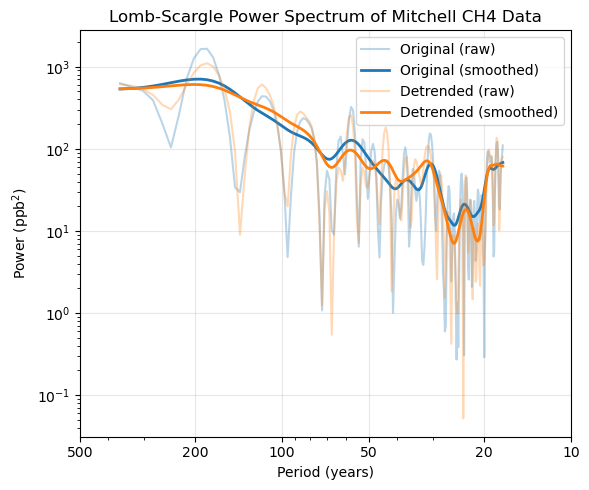


Period range: 17.2 to 363.6 years


In [6]:
# Plot results
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Define custom tick locations and labels
tick_periods = [500, 200, 100, 50, 20, 10]

# Plot power spectra
ax.loglog(
    1 / frequency_original,
    power_original,
    alpha=0.3,
    label="Original (raw)",
    color="tab:blue",
)
ax.loglog(
    1 / frequency_original,
    power_original_smooth,
    label="Original (smoothed)",
    color="tab:blue",
    linewidth=2,
)
ax.loglog(
    1 / frequency_detrended,
    power_detrended,
    alpha=0.3,
    label="Detrended (raw)",
    color="tab:orange",
)
ax.loglog(
    1 / frequency_detrended,
    power_detrended_smooth,
    label="Detrended (smoothed)",
    color="tab:orange",
    linewidth=2,
)
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
# ax.set_ylabel("Power (normalized)")
ax.set_title("Lomb-Scargle Power Spectrum of Mitchell CH4 Data")
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Invert x-axis so period decreases to the right
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)

plt.tight_layout()
plt.show()

# Convert to periods for easier interpretation
periods = 1 / frequency_original
print(f"\nPeriod range: {periods.min():.1f} to {periods.max():.1f} years")

I didn't realize how little data was actually in the mitchell high-resolution dataset. Detrending doesn't do a whole lot, but smoothing gets rid of much of the noise along with add DoF to the spectrum.

# Build simple AR(1) modesl forced by white noise
I'd like to see how well AR(1) models of methane could explain the data. I will generate AR(1) datasets with 8, 10, and 12 year lifetimes targetting the variance of the detrended data.

From testing, a time step of at most 1/48 years is recommended. None of the AR(1) models driven by white noise with reasonable methane decay timescales match the total spectral power in the observations. I'm not exactly sure why, other than a general misfit of the model to the observations.

In [7]:
def generate_ar1_with_spectrum(
    phi,
    sigma_eps,
    n_steps,
    frequency_min,
    frequency_max,
    sigma_idx,
    rng,
):
    """
    Generate AR(1) noise and compute its power spectrum.

    Parameters:
    -----------
    phi : float
        AR(1) coefficient
    sigma_eps : float
        Standard deviation of white noise
    n_steps : int
        Number of time steps
    frequencies : array
        Frequency array for power spectrum
    sigma_idx : int
        Smoothing parameter for Gaussian filter
    rng : numpy random generator
        Random number generator

    Returns:
    --------
    noise : array
        Generated AR(1) time series
    power : array
        Raw power spectrum
    power_smooth : array
        Smoothed power spectrum
    """
    # Generate AR(1) noise
    noise = generate_ar1_noise(phi=phi, sigma_eps=sigma_eps, n_steps=n_steps, rng=rng)

    # Calculate power spectrum using the same frequency range as before
    frequency, power = LombScargle(
        np.arange(0, n_years, dt_years), noise, nterms=1
    ).autopower(
        samples_per_peak=5,
        normalization="psd",
        minimum_frequency=frequency_min,
        maximum_frequency=frequency_max,
    )

    # Smooth the power spectrum
    power_smooth = gaussian_filter1d(power, sigma_idx)

    return noise, frequency, power, power_smooth

In [8]:
tau_arr = np.array([5, 8, 10, 12, 30])  # e-folding timescales in years
n_years = 1000  # number of years to simulate
n_ens = 30  # number of ensemble members
dt_years = 1 / 96  # time step
var_detrended = np.var(mitchell_ch4_detrended, ddof=1)

# generate random seeds
ss = np.random.SeedSequence(12345)
child_seqs = ss.spawn(n_ens)

noise_mapper = {}
psd_mapper = {}
psd_smooth_mapper = {}

for tau in tau_arr:
    # Calculate AR(1) parameters from tau
    phi, sigma_cont, sigma_eps = compute_ar1_params_from_tau(
        tau_days=tau * 365, dt_days=dt_years * 365, variance=var_detrended
    )

    # Lists to store results temporarily
    noise_list = []
    power_list = []
    power_smooth_list = []

    # Loop over ensemble members
    for idx_ens in range(n_ens):
        # Calculate noise and its power spectrum
        noise, frequency_spectrum, power, power_smooth = generate_ar1_with_spectrum(
            phi,
            sigma_eps,
            int(n_years // dt_years),
            frequency_min,
            frequency_max,
            sigma_idx,
            np.random.default_rng(child_seqs[idx_ens]),
        )

        # Store results in lists
        noise_list.append(noise)
        power_list.append(power)
        power_smooth_list.append(power_smooth)

    # Convert lists to arrays - shape based on actual output dimensions
    noise_arr = np.array(noise_list)
    psd_arr = np.array(power_list)
    psd_smooth_arr = np.array(power_smooth_list)

    # Store in mapper
    noise_mapper[tau] = noise_arr
    psd_mapper[tau] = psd_arr
    psd_smooth_mapper[tau] = psd_smooth_arr

In [9]:
# calculate characteristics of the AR(1) fits:
from collections import namedtuple

# Define a simple container for results
FitResult = namedtuple(
    "FitResult",
    ["tau", "period", "psd_smooth", "slope", "se_slope", "intercept", "x_fit", "y_fit"],
)

results = []

for tau in tau_arr:
    # 1) average across ensemble members
    psd = psd_smooth_mapper[tau]  # shape (n_ensembles, n_freq)
    psd_smooth = psd.mean(axis=0)  # now shape (n_freq,)

    # 2) build mask for the period range of interest
    period = 1 / frequency_spectrum
    # mask = (period >= 18) & (period <= 50)
    mask = (period >= 18) & (period <= 80)

    if not np.any(mask):
        print(f"Warning: no data in 18–50 yr band for τ={tau}")
        continue

    # 3) linear regression in log-log space
    x = np.log(period[mask])
    y = np.log(psd_smooth[mask])

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    resid = y - y_pred
    mse = np.sum(resid**2) / (len(x) - 2)
    se_slope = np.sqrt(mse / np.sum((x - x.mean()) ** 2))

    # 4) build fit curve
    x_fit = np.linspace(period[mask].max(), period[mask].min(), 100)
    y_fit = np.exp(intercept) * x_fit**slope

    # 5) store everything
    results.append(
        FitResult(
            tau=tau,
            period=period,
            psd_smooth=psd_smooth,
            slope=slope,
            se_slope=se_slope,
            intercept=intercept,
            x_fit=x_fit,
            y_fit=y_fit,
        )
    )

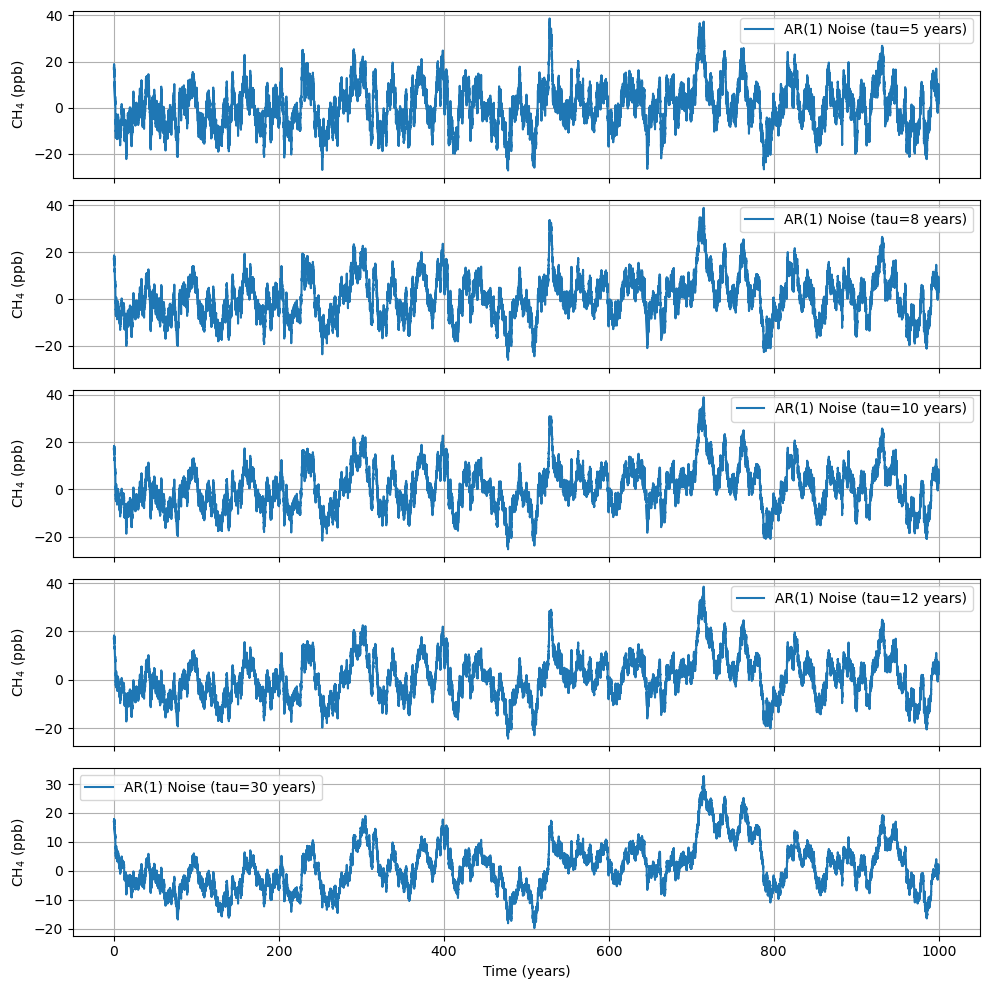

In [10]:
# Plot timeseries of first ensemble member for each tau
fig, axs = plt.subplots(len(tau_arr), 1, figsize=(10, 2 * len(tau_arr)), sharex=True)
for idx, tau in enumerate(tau_arr):
    noise = noise_mapper[tau][0]  # first ensemble member
    time_steps = np.arange(0, n_years, dt_years)

    axs[idx].plot(
        time_steps, noise, label=f"AR(1) Noise (tau={tau} years)", color="tab:blue"
    )
    axs[idx].set_ylabel("CH$_4$ (ppb)")
    axs[idx].legend()
    axs[idx].grid(True)
axs[-1].set_xlabel("Time (years)")
plt.tight_layout()

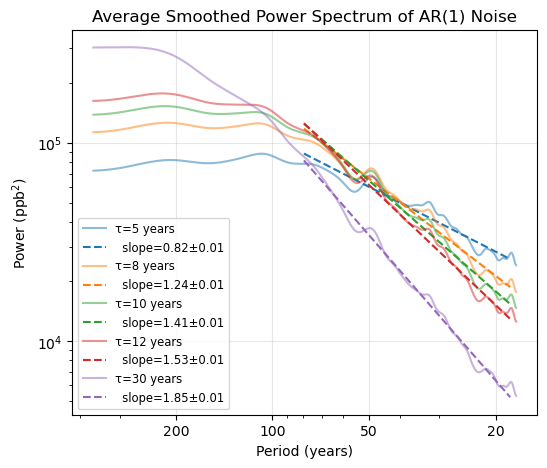

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

for res in results:
    # Plot the smoothed PSD
    ax.loglog(res.period, res.psd_smooth, alpha=0.5, label=f"τ={res.tau} years")

    # Grab the color that Matplotlib just used
    color = ax.get_lines()[-1].get_color()

    # Plot the fit line
    ax.plot(
        res.x_fit,
        res.y_fit,
        linestyle="--",
        color=color,
        label=f"  slope={res.slope:.2f}±{res.se_slope:.2f}",
    )

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("Average Smoothed Power Spectrum of AR(1) Noise")

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Compare AR(1) spectrum to observations 

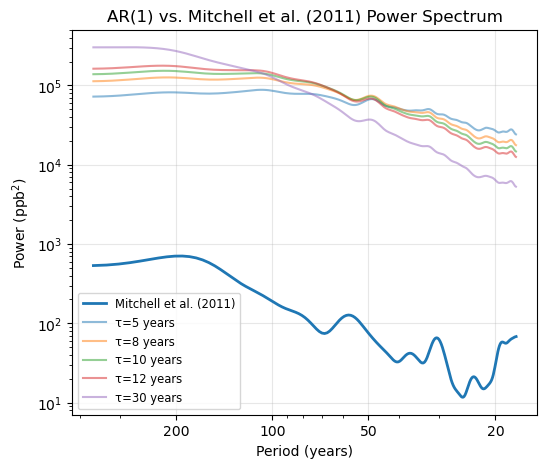

In [12]:
# plot smoothed power spectrum of original data against AR(1) fits
fig, ax = plt.subplots(figsize=(6, 5))

ax.loglog(
    1 / frequency_original,
    power_original_smooth,
    label="Mitchell et al. (2011)",
    color="tab:blue",
    linewidth=2,
)

for res in results:
    # Plot the smoothed PSD
    ax.loglog(res.period, res.psd_smooth, alpha=0.5, label=f"τ={res.tau} years")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("AR(1) vs. Mitchell et al. (2011) Power Spectrum")

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
# ax.set_ylim([1, 1e6])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

In [13]:
# calculate slope of Mitchell et al. (2011) power spectrum from 20 to 200 years
period = 1 / frequency_original
mask = (period >= 20) & (period <= 200)

# 3) linear regression in log-log space
x = np.log(period[mask])
y = np.log(power_original_smooth[mask])

slope_original, intercept_original = np.polyfit(x, y, 1)
y_pred_original = slope_original * x + intercept_original
resid_original = y - y_pred_original
mse_original = np.sum(resid_original**2) / (len(x) - 2)
se_slope_original = np.sqrt(mse_original / np.sum((x - x.mean()) ** 2))

# 4) build fit curve
x_fit_original = np.linspace(period[mask].max(), period[mask].min(), 100)
y_fit_original = np.exp(intercept_original) * x_fit_original**slope_original

Text(0.5, 1.0, 'AR(1) vs. Mitchell et al. (2011) slope')

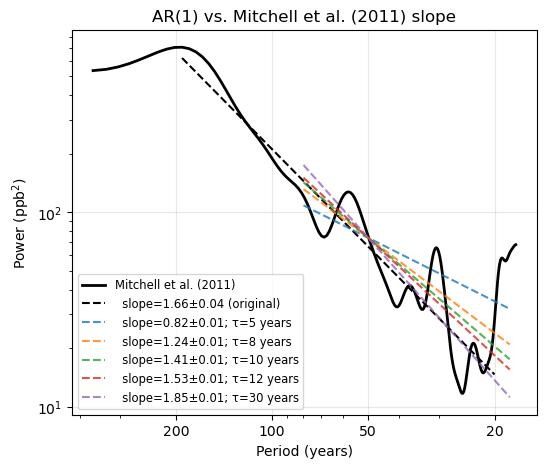

In [14]:
# plot original psd with fit along with AR(1) slopes
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the original data first
ax.loglog(
    1 / frequency_original,
    power_original_smooth,
    label="Mitchell et al. (2011)",
    color="k",
    linewidth=2,
)
ax.plot(
    x_fit_original,
    y_fit_original,
    linestyle="--",
    color="k",
    label=f"  slope={slope_original:.2f}±{se_slope_original:.2f} (original)",
)

# Choose a reference point to align AR(1) lines with Mitchell data
ref_period = 50  # A good reference point in your period range
ref_idx = np.argmin(np.abs(periods - ref_period))  # Find closest index
mitchell_ref_power = power_original_smooth[ref_idx]  # Power at reference point

# Plot AR(1) fit lines aligned with Mitchell data
for res in results:
    # Find the power that would be predicted by the AR(1) model at the reference period
    ref_power_ar1 = np.exp(res.slope * np.log(ref_period) + res.intercept)

    # Calculate scaling factor to match Mitchell data at reference point
    scale_factor = mitchell_ref_power / ref_power_ar1

    # Apply scaling to the whole fit line (preserves slope, adjusts intercept)
    shifted_y_fit = res.y_fit * scale_factor

    # Plot the shifted fit line
    ax.plot(
        res.x_fit,
        shifted_y_fit,
        linestyle="--",
        alpha=0.8,
        label=f"  slope={res.slope:.2f}±{res.se_slope:.2f}; τ={res.tau} years",
    )

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
# ax.set_ylim([1, 5e3])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("AR(1) vs. Mitchell et al. (2011) slope")

A couple of observations about the preceeding analysis:

1. Lomb-Scargle on the Mitchell data is super noisy at frequencies higher than 20 yr$^{-1}$, perhaps mostly due to measurement noise. I've set a pseudo-Nyquist frequency of around 18 years based on the median sampling interval between points, but this can be subjective

2. The simulated timeseries have way too much power compared to the observations. This could be due to the sampling interval of the data. Below, I will test how changing the sampling interval changes the power spectral density as well as how firn air smoothing changes the interpretation of the power spectrum relative to the "true" siganl.

3. Fitting a slope on the data shows how the damping time of methane perturbations affect the transfer of variance from low to high scales. The slope is fitted haphazardly in the Mitchell data, so take it with a grain of salt. The slope is higher than one of the longest reasonable damping times (12 years), which could point to a red noise forcing of the AR(1) processes.

4. scipy and astropy give the same answer for lomb-scargle, but astropy is orders of magnitude faster (12s vs. 1.5 min for 10 ens members x 5 timescales).

5. The main question going forward is what metrics we should be fitting and how we can convincingly show that this stochastic forcing could be important for methane.

# Sampling AR(1) at same points as Mitchell
One reason for the much higher spectral density in the AR(1) processes could be that the mitchell data is sampled at few points pretty irregularly.

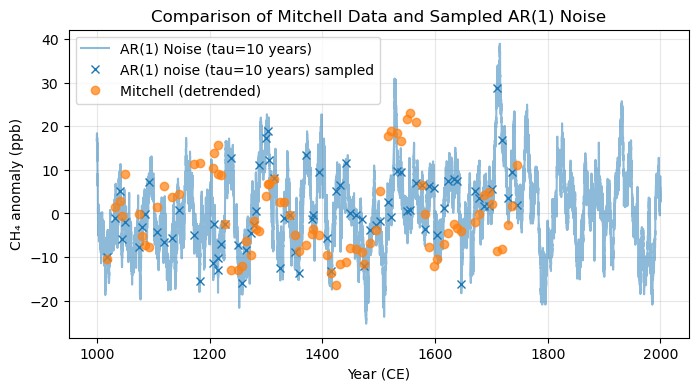

Variance of Mitchell detrended data: 89.76
Variance of noise: 81.45
Variance of sampled noise: 75.51


In [15]:
def sample_noise_at_mitchell_points(
    noise,
    dt_years,
    start_year_mitchell=1000,
    start_year_noise=0,
    mitchell_time=mitchell_time,
):
    """
    Sample a noise realization at the same time points as mitchell_time.

    Parameters:
    -----------
    noise : ndarray
        The noise realization array.
    dt_years : float
        Time step in years used to generate the noise.
    start_year_mitchell : float, optional
        The reference year in the Mitchell data (default: 1000).
    start_year_noise : float, optional
        The year in the noise realization to align with start_year_mitchell.
    mitchell_time : ndarray, optional
        The array of Mitchell time points.

    Returns:
    --------
    sampled_noise : ndarray
        Noise sampled at the mitchell_time points.
    """
    # Create the time array for the noise starting from start_year_noise
    noise_time = np.arange(0, len(noise) * dt_years, dt_years)

    # Map mitchell_time to the noise time space taking into account the different start years
    mapped_time = mitchell_time - start_year_mitchell + start_year_noise

    # Interpolate noise at mapped mitchell time points
    from scipy.interpolate import interp1d

    noise_interpolator = interp1d(
        noise_time,
        noise,
        bounds_error=False,  # Return NaN for out-of-bounds values
        fill_value=np.nan,
    )
    sampled_noise = noise_interpolator(mapped_time)

    # Check for any out-of-bounds points and warn
    if np.any(np.isnan(sampled_noise)):
        n_missing = np.sum(np.isnan(sampled_noise))
        print(f"Warning: {n_missing} points out of bounds when sampling noise")

    return sampled_noise


# Example usage with a single noise realization
tau = 10  # Example timescale
noise = noise_mapper[tau][0]  # Get first realization for this tau

sampled_noise = sample_noise_at_mitchell_points(
    noise, dt_years, start_year_mitchell=1000
)

# Plot comparison to verify
plt.figure(figsize=(8, 4))
time_steps = np.arange(0, n_years, dt_years)
plt.plot(
    time_steps + 1000,
    noise,
    label=f"AR(1) Noise (tau={tau} years)",
    color="tab:blue",
    alpha=0.5,
)
plt.plot(
    mitchell_time, sampled_noise, "x", label=f"AR(1) noise (tau={tau} years) sampled"
)
plt.plot(
    mitchell_time, mitchell_ch4_detrended, "o", label="Mitchell (detrended)", alpha=0.7
)
plt.xlabel("Year (CE)")
plt.ylabel("CH₄ anomaly (ppb)")
plt.title(f"Comparison of Mitchell Data and Sampled AR(1) Noise")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Verify that the variance is similar
print(
    f"Variance of Mitchell detrended data: {np.var(mitchell_ch4_detrended, ddof=1):.2f}"
)
print(f"Variance of noise: {np.var(noise, ddof=1):.2f}")
print(f"Variance of sampled noise: {np.var(sampled_noise, ddof=1):.2f}")

In [16]:
## perform sampling and calculate power spectrum for each ensemble member of each tau
# Create empty dictionaries to store results
noise_sampled_mapper = {}
psd_sampled_mapper = {}
psd_smooth_sampled_mapper = {}

# Loop through each tau value in noise_mapper
for tau in tau_arr:
    print(f"Processing tau = {tau} years")

    # Get the noise array for this tau (shape: n_ens x n_timepoints)
    noise_array = noise_mapper[tau]

    # Initialize lists to store results for this tau
    noise_sampled_list = []
    power_sampled_list = []
    power_smooth_sampled_list = []

    # Loop through each ensemble member
    for i in range(n_ens):
        # Get noise realization
        noise = noise_array[i]

        # Sample at Mitchell time points
        sampled_noise = sample_noise_at_mitchell_points(
            noise, dt_years, start_year_mitchell=1000
        )

        # Calculate power spectrum for sampled noise
        frequency_sampled, power_sampled = LombScargle(
            mitchell_time, sampled_noise, nterms=1
        ).autopower(
            samples_per_peak=5,
            normalization="psd",
            minimum_frequency=frequency_min,
            maximum_frequency=frequency_max,
        )

        # Smooth the power spectrum
        power_smooth_sampled = gaussian_filter1d(power_sampled, sigma_idx)

        # Append results to lists
        noise_sampled_list.append(sampled_noise)
        power_sampled_list.append(power_sampled)
        power_smooth_sampled_list.append(power_smooth_sampled)

    # Convert lists to arrays
    noise_sampled_arr = np.array(noise_sampled_list)
    power_sampled_arr = np.array(power_sampled_list)
    power_smooth_sampled_arr = np.array(power_smooth_sampled_list)

    # Store in dictionaries
    noise_sampled_mapper[tau] = noise_sampled_arr
    psd_sampled_mapper[tau] = power_sampled_arr
    psd_smooth_sampled_mapper[tau] = power_smooth_sampled_arr

print("Sampling and PSD calculation complete!")

Processing tau = 5 years
Processing tau = 8 years
Processing tau = 10 years
Processing tau = 12 years
Processing tau = 30 years
Sampling and PSD calculation complete!


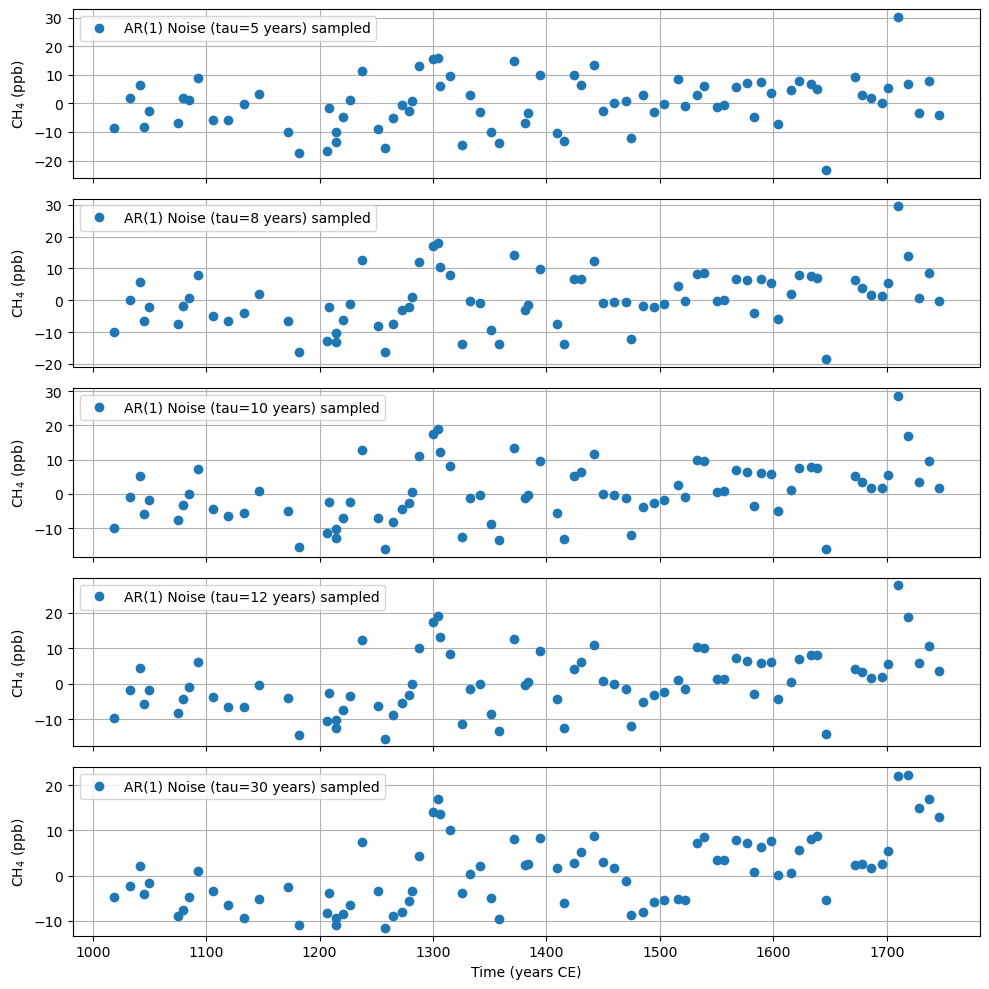

In [17]:
# Plot timeseries of first ensemble member for each tau
fig, axs = plt.subplots(len(tau_arr), 1, figsize=(10, 2 * len(tau_arr)), sharex=True)
for idx, tau in enumerate(tau_arr):
    noise = noise_sampled_mapper[tau][0]  # first ensemble member

    axs[idx].plot(
        mitchell_time,
        noise,
        "o",
        label=f"AR(1) Noise (tau={tau} years) sampled",
        color="tab:blue",
    )
    axs[idx].set_ylabel("CH$_4$ (ppb)")
    axs[idx].legend()
    axs[idx].grid(True)
axs[-1].set_xlabel("Time (years CE)")
plt.tight_layout()

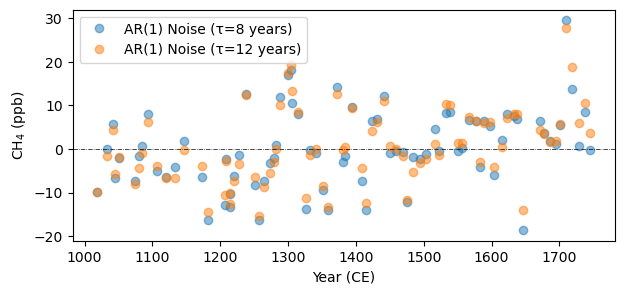

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
noise_1 = noise_sampled_mapper[8][0]
noise_2 = noise_sampled_mapper[12][0]

ax.plot(
    mitchell_time,
    noise_1,
    "o",
    label="AR(1) Noise (τ=8 years)",
    color="tab:blue",
    alpha=0.5,
)
ax.plot(
    mitchell_time,
    noise_2,
    "o",
    label="AR(1) Noise (τ=12 years)",
    color="tab:orange",
    alpha=0.5,
)
ax.axhline(0, color="k", linestyle="-.", linewidth=0.5)
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_xlabel("Year (CE)")
ax.legend()

Text(0.5, 1.0, 'AR(1) vs. Mitchell et al. (2011)')

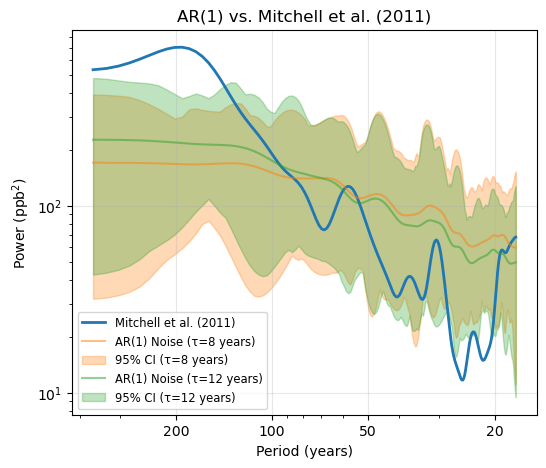

In [19]:
## plot 95% CI for 8 and 12 year AR(1) noise along with mitchell data
fig, ax = plt.subplots(figsize=(6, 5))
# Calculate 2.5th and 97.5th percentiles for 8-year AR(1) noise
tau_8 = 8
power_8 = psd_smooth_sampled_mapper[tau_8].mean(axis=0)
lower_bound_8 = np.percentile(psd_smooth_sampled_mapper[tau_8], 2.5, axis=0)
upper_bound_8 = np.percentile(psd_smooth_sampled_mapper[tau_8], 97.5, axis=0)

# Calculate 2.5th and 97.5th percentiles for 12-year AR(1) noise
tau_12 = 12
power_12 = psd_smooth_sampled_mapper[tau_12].mean(axis=0)
lower_bound_12 = np.percentile(psd_smooth_sampled_mapper[tau_12], 2.5, axis=0)
upper_bound_12 = np.percentile(psd_smooth_sampled_mapper[tau_12], 97.5, axis=0)

# mitchell data
ax.loglog(
    1 / frequency_original,
    power_original_smooth,
    label="Mitchell et al. (2011)",
    color="tab:blue",
    linewidth=2,
)

# Plot 8-year AR(1) noise with 95% CI
ax.loglog(
    1 / frequency_sampled,
    power_8,
    label="AR(1) Noise (τ=8 years)",
    color="tab:orange",
    alpha=0.5,
)
ax.fill_between(
    1 / frequency_sampled,
    lower_bound_8,
    upper_bound_8,
    color="tab:orange",
    alpha=0.3,
    label="95% CI (τ=8 years)",
)

# Plot 12-year AR(1) noise with 95% CI
ax.loglog(
    1 / frequency_sampled,
    power_12,
    label="AR(1) Noise (τ=12 years)",
    color="tab:green",
    alpha=0.5,
)
ax.fill_between(
    1 / frequency_sampled,
    lower_bound_12,
    upper_bound_12,
    color="tab:green",
    alpha=0.3,
    label="95% CI (τ=12 years)",
)

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
# ax.set_ylim([1, 5e3])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("AR(1) vs. Mitchell et al. (2011)")

# Firn air smoothing
Diffusion and gas bubble close-off mean that the data measured in the ice core is smoothed over some time. I'm using a gamma distribution to try to match the WAIS gas age distribution from Mitchell et al. (2013) Figure S7.

In [20]:
from math import gamma
from scipy.optimize import fsolve
import numpy as np


def gamma_kernel_native(k, theta, t_max=200, dt=1.0):
    """
    Build a gamma‐PDF kernel given shape k and scale theta.

    Parameters
    ----------
    k : float
        Shape parameter (often called α) of the gamma distribution.
    theta : float
        Scale parameter (often called θ) of the gamma distribution.
    t_max : float, optional
        Maximum age (years) at which to truncate the kernel (default: 200).
    dt : float, optional
        Time step (years) for discretizing the kernel (default: 1.0).

    Returns
    -------
    t : ndarray
        1D array of time points from 0 to t_max in steps of dt.
    g : ndarray
        Normalized gamma PDF values at each t (i.e. ∫ g(t) dt = 1).
    """
    t = np.arange(0.0, t_max + dt, dt)
    g = (t ** (k - 1)) * np.exp(-t / theta) / ((theta**k) * gamma(k))
    g /= np.trapezoid(g, t)
    return t, g


def fit_gamma_params(mode, fwhm, k0=6.5):
    """
    Find gamma parameters k and theta so that the PDF has a given mode and FWHM.

    Parameters
    ----------
    mode : float
        Desired mode (peak location) of the gamma PDF in years.
    fwhm : float
        Desired full width at half maximum (years).
    k0 : float, optional
        Initial guess for the shape parameter k (default: 6.5).  A value
        around 6.5 produces a mode ≈25 yr and FWHM ≈25 yr, typical for
        WAIS Divide firn smoothing.

    Returns
    -------
    k_fit : float
        Fitted shape parameter k (α).
    theta_fit : float
        Fitted scale parameter θ.
    """

    def equations(params):
        k, theta = params
        # 1) mode constraint: (k-1)*θ = mode
        eq1 = (k - 1) * theta - mode

        # 2) FWHM constraint: solve PDF(t) = half‐peak at two points and enforce their difference = fwhm
        t_mode = (k - 1) * theta

        def pdf(t):
            return (t ** (k - 1)) * np.exp(-t / theta) / ((theta**k) * gamma(k))

        peak = pdf(t_mode)
        half = peak / 2
        t1 = fsolve(lambda t: pdf(t) - half, t_mode * 0.5)[0]
        t2 = fsolve(lambda t: pdf(t) - half, t_mode * 1.5)[0]
        eq2 = (t2 - t1) - fwhm

        return [eq1, eq2]

    k_fit, theta_fit = fsolve(equations, x0=[k0, mode / (k0 - 1)])
    return k_fit, theta_fit


def wais_gamma_kernel(mode=25, fwhm=25, t_max=200, dt=1.0):
    """
    Return the WAIS Divide firn‐smoothing kernel as a gamma PDF.

    Internally fits k and θ to match the specified mode and FWHM, then
    calls gamma_kernel_native.

    Parameters
    ----------
    mode : float, optional
        Target mode of the gamma PDF (years, default=25).
    fwhm : float, optional
        Target full width at half maximum (years, default=25).
    t_max : float, optional
        Kernel truncation age (years, default=200).
    dt : float, optional
        Time step for kernel discretization (years, default=1.0).

    Returns
    -------
    t : ndarray
        Time grid for the kernel (0 to t_max in steps of dt).
    g : ndarray
        Normalized gamma PDF values on t.
    """
    k, theta = fit_gamma_params(mode, fwhm)
    return gamma_kernel_native(k, theta, t_max, dt)


import numpy as np


def firn_convolve(series, kernel_t, kernel_g, dt_series=1.0):
    """
    Convolve a uniformly sampled time-series with a causal firn-air kernel
    using an FFT-based linear convolution.

    Parameters
    ----------
    series : 1-D array_like, shape (N,)
        The atmospheric or model time-series.  It **must** be sampled at a
        constant interval of ``dt_series`` (e.g., one value per year).
    kernel_t : 1-D array_like, shape (M,)
        Time axis (in the same units as ``dt_series``) for the kernel.
        Typically starts at 0 yr and extends to the age where the kernel
        is effectively zero.  The spacing of ``kernel_t`` does **not** have
        to equal ``dt_series``.
    kernel_g : 1-D array_like, shape (M,)
        Kernel values g(t) evaluated at ``kernel_t``.  Must be **causal**
        ( g(t) = 0 for t < 0 ) and non-negative.  The routine normalises
        it to unit area so that the convolution conserves the mean of
        the input series.
    dt_series : float, optional
        Sampling interval of ``series`` (default = 1.0).  Units must match
        those of ``kernel_t`` (e.g. both in yr).

    Returns
    -------
    smoothed : ndarray, shape (N,)
        The series after convolution with the kernel, aligned to the same
        time grid as the input ``series``.

    Notes
    -----
    * The kernel is first interpolated onto the series grid so that the
      convolution is performed on a single, uniform spacing.
    * The FFT length is chosen as the next power of two ≥ (N + L − 1),
      where L is the interpolated kernel length.  This guarantees linear
      (non-circular) convolution and gives near-optimal FFT speed.
    * Result is mathematically identical to
      ``np.convolve(series, kernel_interp, mode="full")[:N]`` but is
      much faster for long records.

    Example
    -------
    >>> t_kernel = np.linspace(0, 200, 401)      # 0–200 yr in 0.5 yr steps
    >>> g_kernel = gamma_pdf(t_kernel, k=6.5, theta=4.55)
    >>> smoothed = firn_convolve(ch4_series, t_kernel, g_kernel)
    """
    # ---------- 1. interpolate kernel onto the series grid ------------------
    max_tau = kernel_t[-1]
    n_kernel_series = int(np.floor(max_tau / dt_series)) + 1
    t_uniform = np.arange(n_kernel_series) * dt_series
    kernel_uniform = np.interp(t_uniform, kernel_t, kernel_g, left=0.0, right=0.0)

    # ensure causal ordering and unit area (mass conservation)
    kernel_uniform = np.maximum(kernel_uniform, 0.0)
    kernel_uniform /= kernel_uniform.sum()  # normalise

    # ---------- 2. FFT-based linear convolution ----------------------------
    N = len(series)
    L = len(kernel_uniform)
    n_fft = 1 << int(np.ceil(np.log2(N + L)))  # next power of 2

    S_f = np.fft.rfft(series, n=n_fft)
    K_f = np.fft.rfft(kernel_uniform, n=n_fft)
    smoothed_full = np.fft.irfft(S_f * K_f, n=n_fft)

    # ---------- 3. trim to original length ---------------------------------
    return smoothed_full[:N]

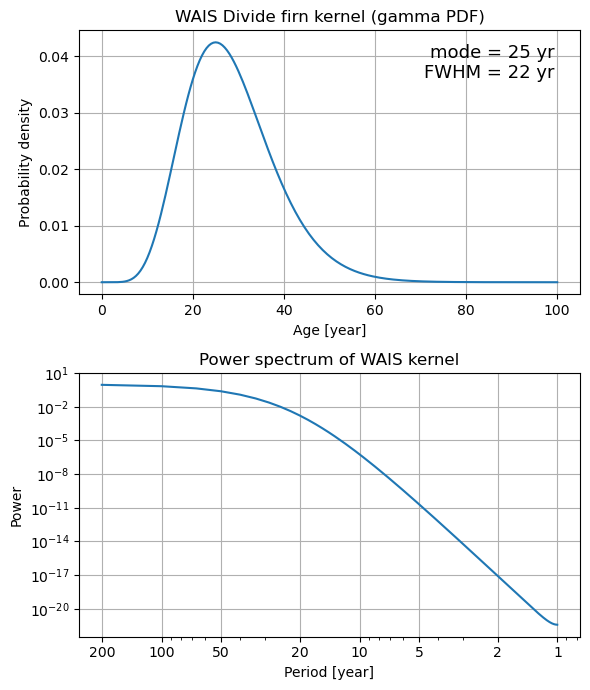

In [21]:
## fit gamma parameters and generate kernel
#  if based on Figure S7 from Mitchell et al. (2013), mode = 25 years and FWHM = 22 years
mode = 25  # years
fwhm = 22  # years
t_ker, g_ker = wais_gamma_kernel(mode=mode, fwhm=fwhm, t_max=200, dt=0.5)

# calculate the power spectrum of the kernel
dt = t_ker[1] - t_ker[0]
G = np.fft.rfft(g_ker) * dt
freq = np.fft.rfftfreq(t_ker.size, d=dt)  # cy yr⁻¹
psd_kernel = (G * np.conj(G)).real  # |G(f)|²

# Create a figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), sharex=False)

# Top: Plot the firn kernel
mask = t_ker <= 100
ax1.plot(t_ker[mask], g_ker[mask], label="WAIS Divide firn kernel", color="tab:blue")
# annotate mode and FWHM in the top-right corner
ax1.text(
    0.95,
    0.95,
    f"mode = {mode} yr\nFWHM = {fwhm} yr",
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)
ax1.set_xlabel("Age [year]")
ax1.set_ylabel("Probability density")
ax1.set_title("WAIS Divide firn kernel (gamma PDF)")
ax1.grid(True)

# Bottom: Plot the power spectrum with Period on the x-axis and Power on the y-axis
period = 1 / freq[1:]
ax2.loglog(period, psd_kernel[1:])
ax2.set_xlabel("Period [year]")
ax2.set_ylabel("Power")
ax2.set_title("Power spectrum of WAIS kernel")
ax2.grid(True)
ax2.invert_xaxis()
tick_periods = [p for p in [200, 100, 50, 20, 10, 5, 2, 1] if p <= res.period.max()]
ax2.set_xticks(tick_periods)
ax2.set_xticklabels(tick_periods)

plt.tight_layout()
plt.show()

In [22]:
## (1) convolve all AR(1) noise realizations with the firn kernel,
#  (2) calculate power spectrum of the smoothed noise,
#  (3) sample at Mitchell time points (offset by 100 years so that 0s are not sampled), and
#  (4) calculate power spectrum of the sampled noise

# Create empty dictionaries to store results
noise_firn_mapper = {}
psd_firn_mapper = {}
psd_firn_smooth_mapper = {}
noise_firn_sampled_mapper = {}
psd_firn_sampled_mapper = {}
psd_firn_smooth_sampled_mapper = {}
psd_firn_smooth_sampled_scaled_mapper = {}

# Loop through each tau value in noise_mapper
for tau in tau_arr:
    print(f"Processing tau = {tau} years")

    # Get the noise array for this tau (shape: n_ens x n_timepoints)
    noise_array = noise_mapper[tau]

    # Initialize lists to store results for this tau
    noise_firn_list = []
    power_firn_list = []
    power_firn_smooth_list = []
    noise_firn_sampled_list = []
    power_firn_sampled_list = []
    power_firn_smooth_sampled_list = []
    power_firn_smooth_sampled_scaled_list = []

    # Loop through each ensemble member
    for i in range(n_ens):
        # Get noise realization
        noise = noise_array[i]

        # (1) Convolve with firn kernel
        noise_firn = firn_convolve(noise, t_ker, g_ker, dt_series=dt_years)

        # (2) Calculate power spectrum of the smoothed noise
        frequency_firn, power_firn = LombScargle(
            np.arange(0, n_years, dt_years), noise_firn, nterms=1
        ).autopower(
            samples_per_peak=5,
            normalization="psd",
            minimum_frequency=frequency_min,
            maximum_frequency=frequency_max,
        )

        # Smooth the power spectrum
        power_firn_smooth = gaussian_filter1d(power_firn, sigma_idx)

        # (3) Sample at Mitchell time points (offset by 100 years)
        sampled_noise_firn = sample_noise_at_mitchell_points(
            noise_firn, dt_years, start_year_mitchell=1000, start_year_noise=100
        )
        # SCALE sampled noise to match the variance of Mitchell data
        sampled_noise_firn_scaled = sampled_noise_firn * (
            np.std(mitchell_ch4_detrended, ddof=1) / np.std(sampled_noise_firn, ddof=1)
        )

        # (4) Calculate power spectrum of the sampled noise
        frequency_sampled_firn, power_sampled_firn = LombScargle(
            mitchell_time, sampled_noise_firn, nterms=1
        ).autopower(
            samples_per_peak=5,
            normalization="psd",
            minimum_frequency=frequency_min,
            maximum_frequency=frequency_max,
        )
        _, power_sampled_firn_scaled = LombScargle(
            mitchell_time, sampled_noise_firn_scaled, nterms=1
        ).autopower(
            samples_per_peak=5,
            normalization="psd",
            minimum_frequency=frequency_min,
            maximum_frequency=frequency_max,
        )

        # Smooth the sampled power spectrum
        power_sampled_firn_smooth = gaussian_filter1d(power_sampled_firn, sigma_idx)
        power_sampled_firn_smooth_scaled = gaussian_filter1d(
            power_sampled_firn_scaled, sigma_idx
        )

        # Append results to lists
        noise_firn_list.append(noise_firn)
        power_firn_list.append(power_firn)
        power_firn_smooth_list.append(power_firn_smooth)

        noise_firn_sampled_list.append(sampled_noise_firn)
        power_firn_sampled_list.append(power_sampled_firn)
        power_firn_smooth_sampled_list.append(power_sampled_firn_smooth)
        power_firn_smooth_sampled_scaled_list.append(power_sampled_firn_smooth_scaled)

    # Convert lists to arrays
    noise_firn_arr = np.array(noise_firn_list)
    power_firn_arr = np.array(power_firn_list)
    power_firn_smooth_arr = np.array(power_firn_smooth_list)
    noise_firn_sampled_arr = np.array(noise_firn_sampled_list)
    power_firn_sampled_arr = np.array(power_firn_sampled_list)
    power_firn_smooth_sampled_arr = np.array(power_firn_smooth_sampled_list)
    power_firn_smooth_sampled_scaled_arr = np.array(
        power_firn_smooth_sampled_scaled_list
    )

    # Store in dictionaries
    noise_firn_mapper[tau] = noise_firn_arr
    psd_firn_mapper[tau] = power_firn_arr
    psd_firn_smooth_mapper[tau] = power_firn_smooth_arr
    noise_firn_sampled_mapper[tau] = noise_firn_sampled_arr
    psd_firn_sampled_mapper[tau] = power_firn_sampled_arr
    psd_firn_smooth_sampled_mapper[tau] = power_firn_smooth_sampled_arr
    psd_firn_smooth_sampled_scaled_mapper[tau] = power_firn_smooth_sampled_scaled_arr

Processing tau = 5 years
Processing tau = 8 years
Processing tau = 10 years
Processing tau = 12 years
Processing tau = 30 years


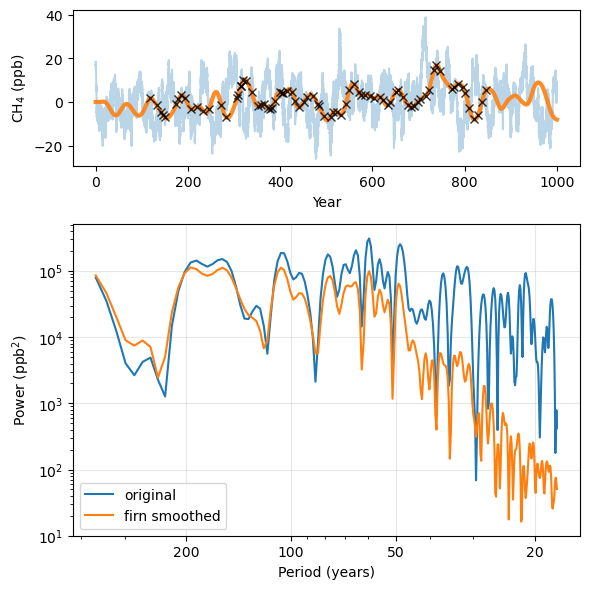

In [23]:
# plot data for just tau = 8 years to verify that the smooething + sampling works
tau = 8  # Example timescale
noise = noise_mapper[tau][0]  # Get first realization for this tau
noise_firn = noise_firn_mapper[tau][0]  # first ensemble
noise_firn_sampled = noise_firn_sampled_mapper[tau][0]  # first ensemble

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6, 6), gridspec_kw={"height_ratios": [1, 2]}
)
# Timeseries
time_steps = np.arange(0, n_years, dt_years)
ax1.plot(
    time_steps, noise, label=f"AR(1) Noise (τ={tau} years)", color="tab:blue", alpha=0.3
)
ax1.plot(
    time_steps,
    noise_firn,
    label=f"AR(1) Noise (τ={tau} years) smoothed",
    color="tab:orange",
    alpha=0.9,
    linewidth=3,
)

ax1.plot(
    mitchell_time - 1000 + 100,
    noise_firn_sampled,
    "x",
    label=f"AR(1) noise (τ={tau} years) sampled",
    color="k",
    alpha=0.8,
)

ax1.set_ylabel("CH$_4$ (ppb)")
ax1.set_xlabel("Year")

# Power spectrum
psd_ar1 = psd_mapper[tau][0]  # first ensemble member
psd_firn = psd_firn_mapper[tau][0]  # first ensemble member

ax2.loglog(1 / frequency_spectrum, psd_ar1, label=f"original", color="tab:blue")
ax2.loglog(1 / frequency_firn, psd_firn, label=f"firn smoothed", color="tab:orange")
ax2.set_xlabel("Period (years)")
ax2.set_ylabel("Power (ppb$^2$)")
ax2.invert_xaxis()
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax2.set_xticks(tick_periods)
ax2.set_xticklabels(tick_periods)

plt.tight_layout()

Variance in the unsmoothed noise: 81.45 ppb^2
Variance in the firn-smoothed, sampled noise: 28.36 ppb^2


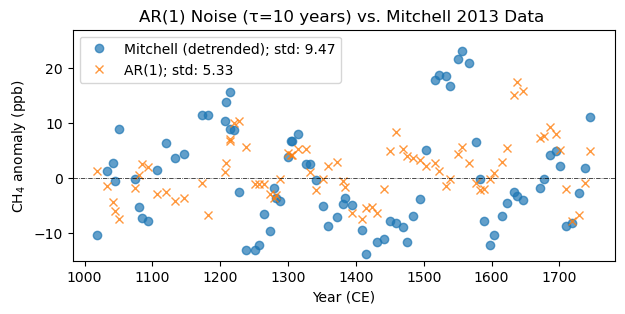

In [30]:
# Plot firn-smoothed sampled tau = 8 years noise against Mitchell data
fig, ax = plt.subplots(figsize=(7, 3))
tau = 10
noise_firn_sampled = noise_firn_sampled_mapper[tau][0]
noise = noise_mapper[tau][0]
print(
    f"Variance in the unsmoothed noise: {np.var(noise, ddof=1):0.2f} ppb^2\n"
    + f"Variance in the firn-smoothed, sampled noise: {np.var(noise_firn_sampled, ddof=1):0.2f} ppb^2"
)

# Compute variances
std_mitchell = np.std(mitchell_ch4_detrended, ddof=1)
std_noise = np.std(noise_firn_sampled, ddof=1)

ax.plot(
    mitchell_time,
    mitchell_ch4_detrended,
    "o",
    label=f"Mitchell (detrended); std: {std_mitchell:0.2f}",
    color="tab:blue",
    alpha=0.7,
)
ax.plot(
    mitchell_time,
    noise_firn_sampled,
    "x",
    label=f"AR(1); std: {std_noise:0.2f}",
    color="tab:orange",
    alpha=0.8,
)
ax.axhline(0, color="k", linestyle="-.", linewidth=0.5)

ax.set_ylabel("CH$_4$ anomaly (ppb)")
ax.set_xlabel("Year (CE)")
ax.set_title(f"AR(1) Noise (τ={tau} years) vs. Mitchell 2013 Data ")
ax.set_ylim(-15, 27)
ax.legend()
plt.show()

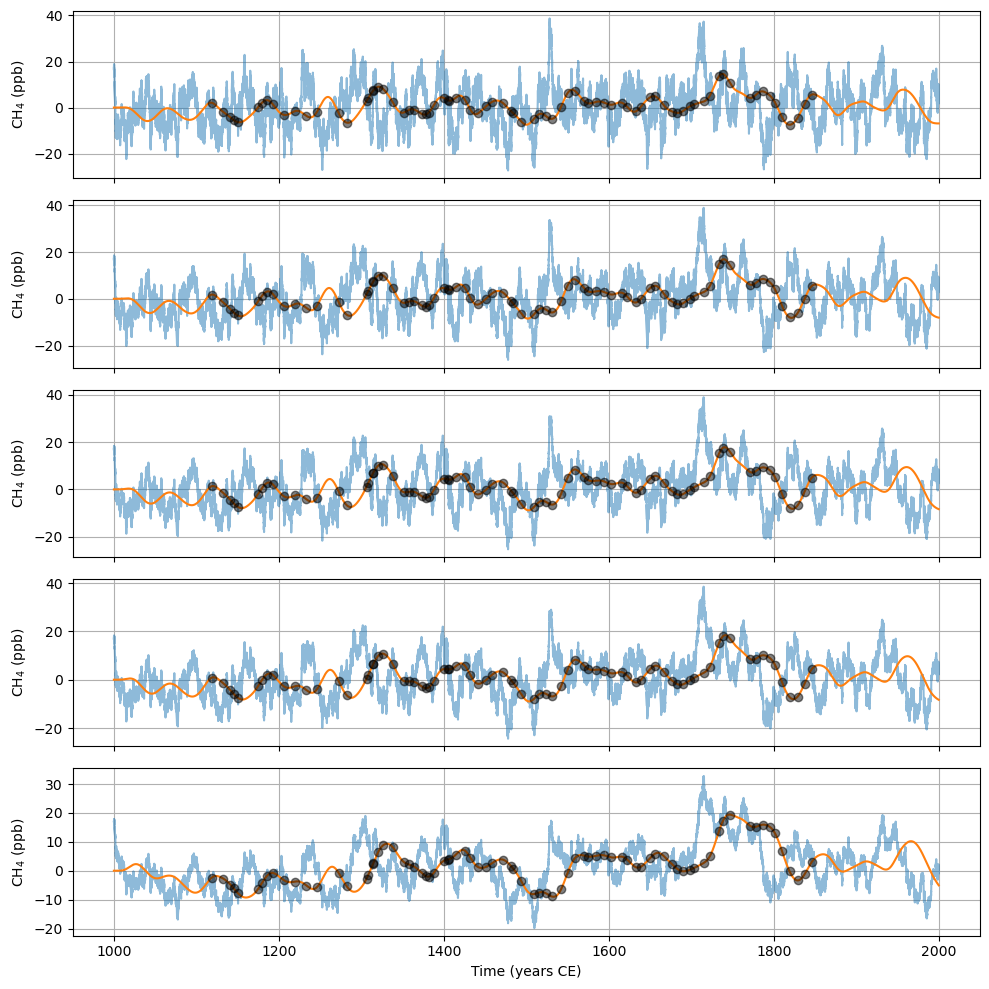

In [25]:
# original timeseries, smoothed timeseries, and smoothed + sampled timeseries
fig, axs = plt.subplots(len(tau_arr), 1, figsize=(10, 2 * len(tau_arr)), sharex=True)
for idx, tau in enumerate(tau_arr):
    noise = noise_mapper[tau][0]  # first ensemble member
    noise_firn = noise_firn_mapper[tau][0]  # first ensemble member, convolved
    noise_firn_sampled = noise_firn_sampled_mapper[tau][
        0
    ]  # first ensemble member, convolved and sampled
    axs[idx].plot(
        np.arange(0, n_years, dt_years) + 1000,
        noise,
        label=f"AR(1) Noise (τ={tau} years)",
        color="tab:blue",
        alpha=0.5,
    )
    axs[idx].plot(
        np.arange(0, n_years, dt_years) + 1000,
        noise_firn,
        label=f"AR(1) Noise (τ={tau} years)",
        color="tab:orange",
    )
    axs[idx].plot(
        mitchell_time + 100,
        noise_firn_sampled,
        "o",
        label=f"AR(1) Noise (τ={tau} years) sampled",
        color="k",
        alpha=0.5,
    )
    axs[idx].set_ylabel("CH$_4$ (ppb)")
    # axs[idx].legend()
    axs[idx].grid(True)
axs[-1].set_xlabel("Time (years CE)")
plt.tight_layout()

Text(0.5, 1.0, 'AR(1) vs. Mitchell et al. (2011)')

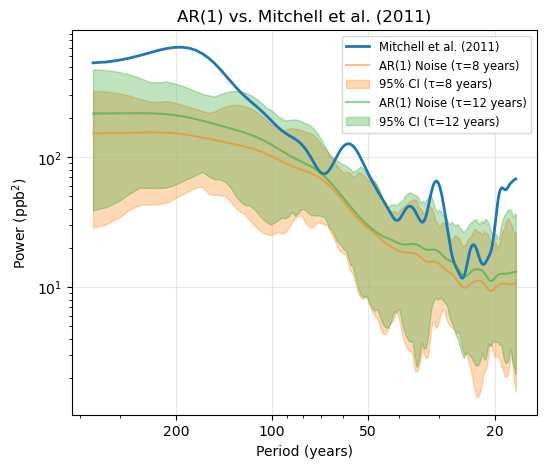

In [26]:
## plot 95% CI for 8 and 12 year AR(1) noise smoothed by the firn along with mitchell data
scale_variance = False

if scale_variance:
    psd_plot_mapper = psd_firn_smooth_sampled_scaled_mapper
else:
    psd_plot_mapper = psd_firn_smooth_sampled_mapper

# Calculate 2.5th and 97.5th percentiles for 8-year AR(1) noise
tau_8 = 8
power_8_firn = psd_plot_mapper[tau_8].mean(axis=0)
lower_bound_8_firn = np.percentile(psd_plot_mapper[tau_8], 2.5, axis=0)
upper_bound_8_firn = np.percentile(psd_plot_mapper[tau_8], 97.5, axis=0)

# Calculate 2.5th and 97.5th percentiles for 12-year AR(1) noise
tau_12 = 12
power_12_firn = psd_plot_mapper[tau_12].mean(axis=0)
lower_bound_12_firn = np.percentile(psd_plot_mapper[tau_12], 2.5, axis=0)
upper_bound_12_firn = np.percentile(psd_plot_mapper[tau_12], 97.5, axis=0)


fig, ax = plt.subplots(figsize=(6, 5))
# mitchell data
ax.loglog(
    1 / frequency_original,
    power_original_smooth,
    label="Mitchell et al. (2011)",
    color="tab:blue",
    linewidth=2,
)

# Plot 8-year AR(1) noise with 95% CI
ax.loglog(
    1 / frequency_sampled,
    power_8_firn,
    label="AR(1) Noise (τ=8 years)",
    color="tab:orange",
    alpha=0.5,
)
ax.fill_between(
    1 / frequency_sampled,
    lower_bound_8_firn,
    upper_bound_8_firn,
    color="tab:orange",
    alpha=0.3,
    label="95% CI (τ=8 years)",
)

# Plot 12-year AR(1) noise with 95% CI
ax.loglog(
    1 / frequency_sampled,
    power_12_firn,
    label="AR(1) Noise (τ=12 years)",
    color="tab:green",
    alpha=0.5,
)
ax.fill_between(
    1 / frequency_sampled,
    lower_bound_12_firn,
    upper_bound_12_firn,
    color="tab:green",
    alpha=0.3,
    label="95% CI (τ=12 years)",
)

# Custom ticks (guard against out-of-range)
tick_periods = [p for p in [500, 200, 100, 50, 20] if p <= res.period.max()]
ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
# ax.set_ylim([1, 5e3])
ax.invert_xaxis()
ax.grid(alpha=0.3)
# Combine the labels neatly
ax.legend(loc="best", fontsize="small")

# Labels, grid, legend
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb$^2$)")
ax.set_title("AR(1) vs. Mitchell et al. (2011)")